# clustering

In [27]:
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.cluster import DBSCAN, KMeans
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split


## test/train

In [28]:
df_all = pd.read_csv('goedeoutput.csv')

In [29]:
df_all = df_all.drop_duplicates(subset='file')
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.575868,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.916088,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.862473,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.736694,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434


In [30]:
colomn_names = df_all.columns
colomn_names

# colomnen verwijderen
feature_names=['time', 'x', 'y', 'z', 'abs', 'roadtype', 'weather',
       'x_std', 'z_std', 'x_mean',
       'x_rms', 'z_rms',
       'z_spectral_flatness']
Y = df_all['weight']
X = df_all[feature_names]
X = pd.get_dummies(X, columns=['weather','roadtype'], drop_first=True, dtype=int)
#Y = pd.get_dummies(Y, columns=['roadtype'], drop_first=True, dtype=int)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## model

In [31]:
pipeline = make_pipeline(StandardScaler(), DBSCAN()) #max_iter=1000, tol=1e-3))

param_grid = {
    'dbscan__eps': [0.2,0.5,1],
    'dbscan__leaf_size': [15, 30, 45],
    'dbscan__min_samples': [5, 10]


}
grid_cv = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=4, 
                       cv=7, 
                       verbose=2) 

grid_cv.fit(x_train, y_train)


TypeError: If no scoring is specified, the estimator passed should have a 'score' method. The estimator Pipeline(steps=[('standardscaler', StandardScaler()), ('dbscan', DBSCAN())]) does not.

In [ ]:
# Perform DBSCAN clustering
epsilon = 0.7  # Chosen based on k-distance graph
min_samples = 6  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(x_train)
# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_train[:, 0], x_train[:, 1], c=clusters, cmap='viridis')
plt.legend()
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

InvalidIndexError: (slice(None, None, None), 0)

<Figure size 1000x600 with 0 Axes>

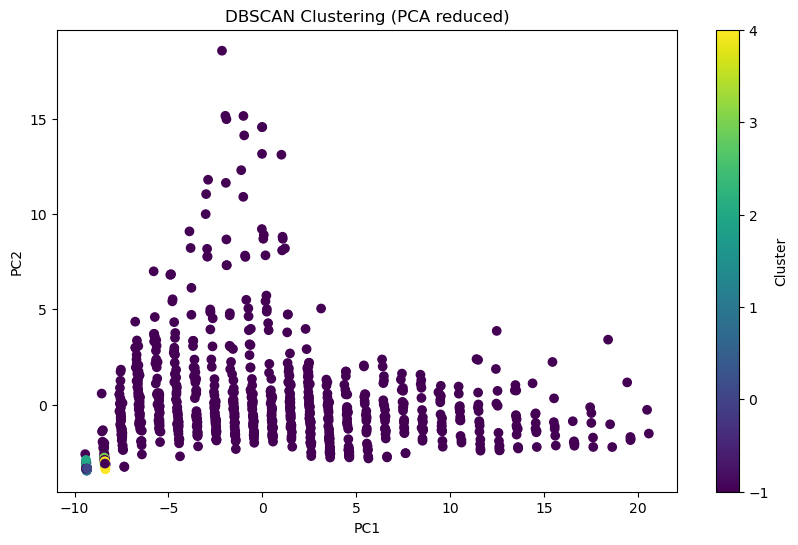

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# DBSCAN
epsilon = 0.7
min_samples = 6

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(x_train)

# PCA → 12D → 2D
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(x_train)

# Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=clusters, cmap='viridis')

plt.title('DBSCAN Clustering (PCA reduced)')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.colorbar(label='Cluster')
plt.show()

In [ ]:
from sklearn import metrics
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = metrics.adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

NameError: name 'labels' is not defined

In [ ]:
KMeans.fit(x_train)

AttributeError: 'DataFrame' object has no attribute '_validate_params'

In [32]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=2, random_state=42)

clusters = model.fit_predict(X)
df_all['cluster']=clusters

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


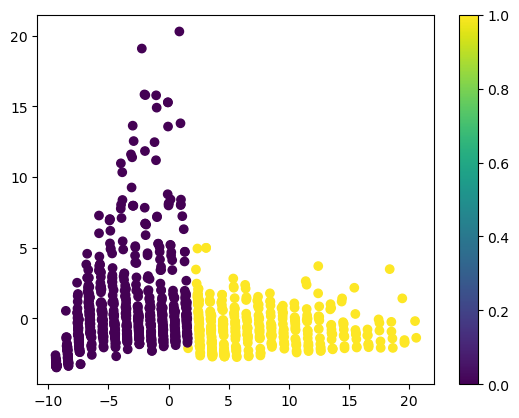

In [36]:
psa = PCA(n_components=2)

x_psa =  psa.fit_transform(X)
plt.scatter(x_psa[:,0],x_psa[:,1], c= clusters)
plt.colorbar()

In [41]:
df_all.x.value_counts

<bound method IndexOpsMixin.value_counts of 0        -0.388200
99       -0.180555
199      -4.626964
298       3.016697
398      -0.492856
            ...   
120896    0.656172
120997    0.064936
121097    0.054262
121197   -0.465913
121298    0.392996
Name: x, Length: 1107, dtype: float64>

ValueError: x and y must be the same size

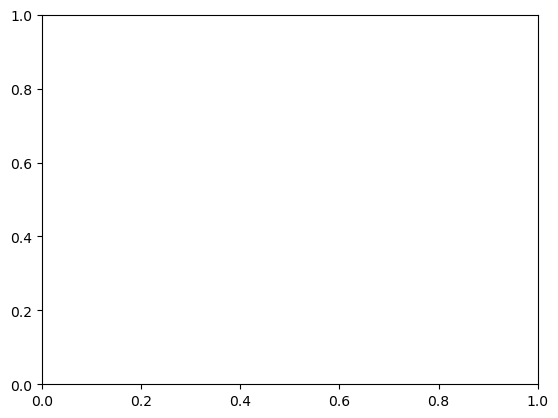

In [48]:
plt.scatter(df_all.x.value_counts(), df_all.z)

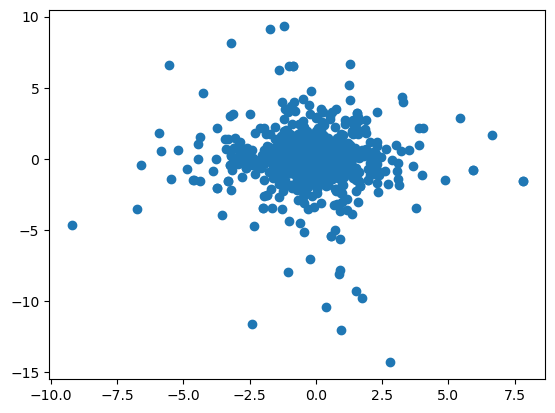

In [37]:
plt.scatter(df_all.x, df_all.y)

In [33]:
df_all

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness,cluster
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.00,Dry,Laurence & Doris,...,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138,0
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.00,Dry,Laurence & Doris,...,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400,0
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.00,Dry,Laurence & Doris,...,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212,0
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.00,Dry,Laurence & Doris,...,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190,0
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.00,Dry,Laurence & Doris,...,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120896,22.004517,0.656172,0.098579,-0.148127,0.679869,zand_5kg_second_22,sand,5.75,Wet,Liz & Renske,...,-0.253706,0.008000,0.149668,0.633183,1.684808,2.056143,0.628787,0.560213,0.579388,1
120997,23.009828,0.064936,2.168097,1.586151,2.687143,zand_5kg_second_23,sand,5.75,Wet,Liz & Renske,...,0.095871,-0.069747,0.121144,0.713378,1.350980,1.702503,0.717287,0.681901,0.643996,1
121097,24.005186,0.054262,-1.209899,0.453583,1.293266,zand_5kg_second_24,sand,5.75,Wet,Liz & Renske,...,0.035572,-0.780466,1.578790,0.706340,2.208710,3.108693,0.741640,0.602472,0.550879,1
121197,25.000545,-0.465913,-2.656772,3.367562,4.314625,zand_5kg_second_25,sand,5.75,Wet,Liz & Renske,...,-0.177443,-0.554232,1.005843,0.847816,1.113331,1.846340,0.666976,0.591709,0.551925,1
